In [18]:
%matplotlib inline

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from numpy.random import seed
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical


In [19]:
# Import data

data_path = Path("../../data/processed/linearized_session_windows_30min.csv")
df = pd.read_csv(data_path)

display(df.head())
print(f"Rows and columns: {df.shape}")
print("\nfocus_scores:")
display(df["focus_score"].value_counts().sort_index().rename("rows_per_focus_score"))

display(df.describe().round(2))


,focus_score,temperature_latest,temperature_mean,temperature_min,temperature_max,temperature_std,temperature_count,temperature_range,humidity_latest,humidity_mean,...,noise_std,noise_count,noise_range,co2_latest,co2_mean,co2_min,co2_max,co2_std,co2_count,co2_range
0,4,19.3,18.533333,17.7,19.3,0.662319,6,1.6,3249.0,3211.333333,...,0.584052,6,1.426495,0.000443,0.000441,0.000434,0.000447,0.000005,6,0.000013
1,3,19.7,19.700000,19.5,19.8,0.126491,6,0.3,2809.0,3026.333333,...,0.305899,6,0.963637,0.000723,0.000541,0.000448,0.000723,0.000110,6,0.000275
2,3,19.4,19.450000,19.4,19.6,0.083666,6,0.2,2401.0,2551.166667,...,0.276514,6,0.699567,0.001179,0.001028,0.000835,0.001179,0.000134,6,0.000344
3,4,19.3,19.233333,19.0,19.4,0.163299,6,0.4,2209.0,2256.833333,...,0.335663,6,0.826070,0.001261,0.001301,0.001238,0.001391,0.000057,6,0.000153
4,4,19.9,19.716667,19.5,19.9,0.147196,6,0.4,2025.0,2100.833333,...,0.146968,6,0.447463,0.001239,0.001240,0.001188,0.001294,0.000042,6,0.000106


Rows and columns: (90453, 36)

focus_scores:


focus_score
1     1290
2    10777
3    43229
4    23368
5    11789
Name: rows_per_focus_score, dtype: int64

,focus_score,temperature_latest,temperature_mean,temperature_min,temperature_max,temperature_std,temperature_count,temperature_range,humidity_latest,humidity_mean,...,noise_std,noise_count,noise_range,co2_latest,co2_mean,co2_min,co2_max,co2_std,co2_count,co2_range
count,90453.00,90453.00,90453.00,90453.00,90453.00,90453.00,90453.00,90453.00,90453.00,90453.00,...,90453.00,90453.00,90453.00,90453.0,90453.0,90453.0,90453.0,90453.0,90453.00,90453.0
mean,3.37,22.22,22.22,22.16,22.28,0.05,10.48,0.13,2737.91,2737.72,...,0.20,10.48,0.54,0.0,0.0,0.0,0.0,0.0,10.48,0.0
std,0.90,3.01,3.01,3.02,3.00,0.08,9.58,0.21,727.36,726.95,...,0.20,9.58,0.49,0.0,0.0,0.0,0.0,0.0,9.58,0.0
min,1.00,10.20,10.27,10.20,10.30,0.00,1.00,0.00,489.52,490.50,...,0.00,1.00,0.00,0.0,0.0,0.0,0.0,0.0,1.00,0.0
25%,3.00,20.00,20.00,19.90,20.10,0.00,6.00,0.00,2209.00,2224.83,...,0.04,6.00,0.09,0.0,0.0,0.0,0.0,0.0,6.00,0.0
50%,3.00,22.02,22.04,22.00,22.10,0.04,6.00,0.10,2704.00,2721.50,...,0.14,6.00,0.43,0.0,0.0,0.0,0.0,0.0,6.00,0.0
75%,4.00,23.90,23.92,23.88,24.00,0.05,6.00,0.12,3249.00,3249.00,...,0.31,6.00,0.89,0.0,0.0,0.0,0.0,0.0,6.00,0.0
max,5.00,33.10,33.07,32.90,33.50,2.48,30.00,6.10,5184.00,5184.00,...,1.60,30.00,3.45,0.0,0.0,0.0,0.0,0.0,30.00,0.0


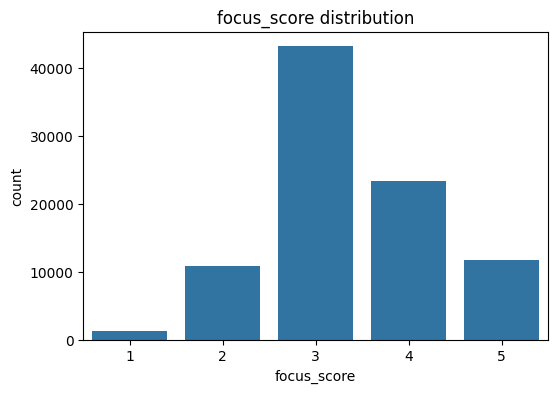

temperature_mean     -0.046
temperature_min      -0.046
temperature_latest   -0.046
temperature_max      -0.046
light_mean           -0.028
light_max            -0.026
light_latest         -0.024
light_min            -0.018
temperature_count     0.017
humidity_count        0.017
light_count           0.017
noise_count           0.017
co2_count             0.017
co2_std              -0.009
co2_range            -0.007
light_range          -0.005
temperature_range     0.005
noise_std            -0.005
temperature_std       0.004
light_std            -0.004
co2_min               0.004
co2_mean              0.003
humidity_latest       0.003
humidity_max          0.003
humidity_mean         0.003
co2_latest            0.003
humidity_range        0.003
humidity_min          0.003
co2_max               0.002
humidity_std          0.001
noise_latest         -0.000
noise_range           0.000
noise_max             0.000
noise_mean            0.000
noise_min            -0.000
Name: correlation_wi

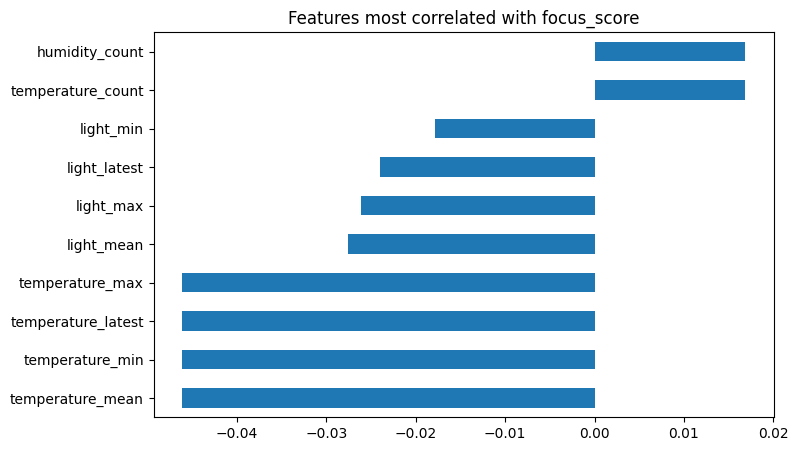

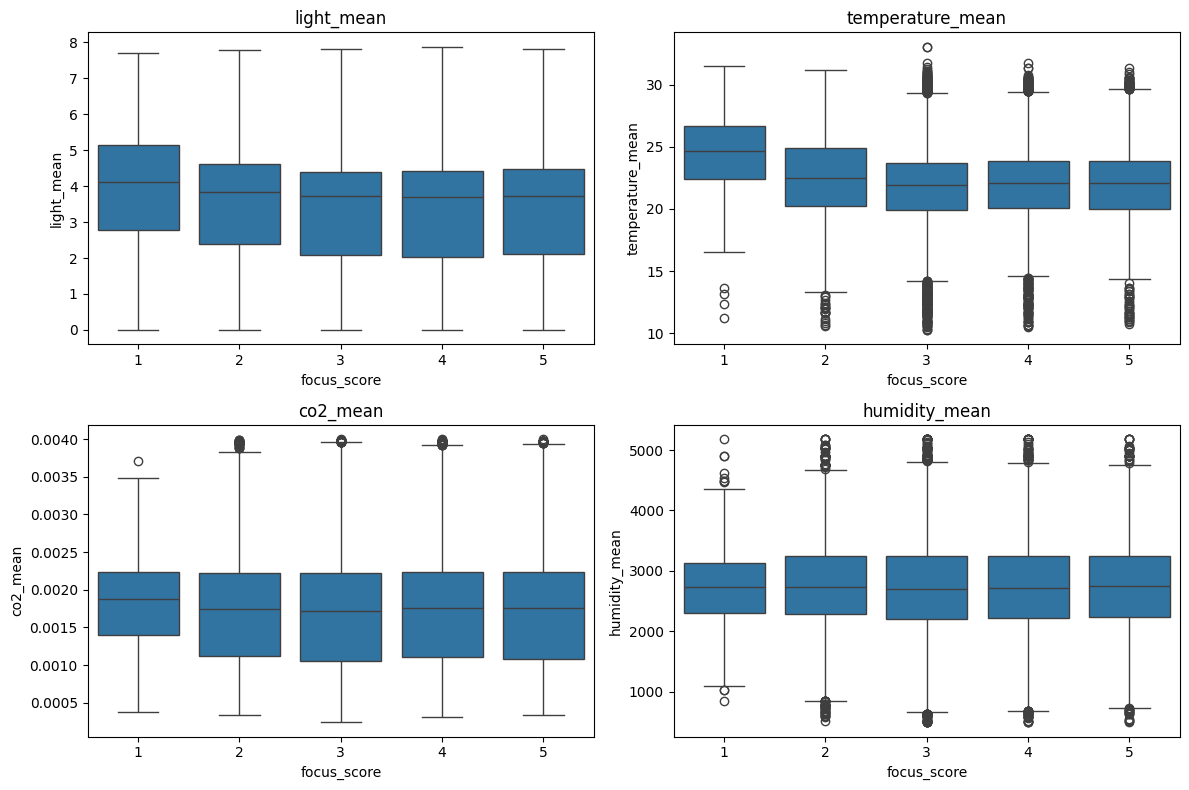

In [20]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="focus_score", order=sorted(df["focus_score"].unique()))
plt.title("focus_score distribution")
plt.show()

corr = df.corr(numeric_only=True)["focus_score"].drop("focus_score")
corr = corr.sort_values(key=lambda x: x.abs(), ascending=False)

display(corr.round(3).rename("correlation_with_focus_score"))

plt.figure(figsize=(8, 5))
corr.head(10).sort_values().plot(kind="barh")
plt.title("Features most correlated with focus_score")
plt.show()

important_features = ["light_mean", "temperature_mean", "co2_mean", "humidity_mean"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feature in zip(axes.flatten(), important_features):
    sns.boxplot(data=df, x="focus_score", y=feature, ax=ax)
    ax.set_title(feature)

plt.tight_layout()
plt.show()


In [21]:
# Split, scale, encode

TARGET_COLUMN = "focus_score"

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

focus_score_values = sorted(y.unique())
focus_score_to_index = {focus_score: index for index, focus_score in enumerate(focus_score_values)}
index_to_focus_score = {index: focus_score for focus_score, index in focus_score_to_index.items()}
num_classes = len(focus_score_values)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

y_train_index = y_train.map(focus_score_to_index).to_numpy()
y_val_index = y_val.map(focus_score_to_index).to_numpy()
y_test_index = y_test.map(focus_score_to_index).to_numpy()

Y_train = to_categorical(y_train_index, num_classes)
Y_val = to_categorical(y_val_index, num_classes)
Y_test = to_categorical(y_test_index, num_classes)

input_size = X_train_scaled.shape[1]

display(pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "validation": y_val.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index()
}).fillna(0))


,train,validation,test
focus_score,,,
1,826,206,258
2,6897,1725,2155
3,27666,6917,8646
4,14955,3739,4674
5,7545,1886,2358


In [22]:
# Helper functions

def reset_seeds():
    seed(0)
    random.seed(0)
    tf.random.set_seed(0)

def build_model(hidden_layers, optimizer_name="sgd", learning_rate=0.05, dropout=0):
    reset_seeds()
    
    model = Sequential()
    model.add(Input(shape=(input_size,)))
    
    for units in hidden_layers:
        model.add(Dense(units=units, activation="relu"))
        if dropout > 0:
            model.add(Dropout(dropout))
            
    model.add(Dense(units=num_classes, activation="softmax"))
    
    if optimizer_name == "sgd":
        optimizer = SGD(learning_rate=learning_rate)
    else:
        optimizer = Adam(learning_rate=learning_rate)
        
    model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model

def decode_predictions(probabilities):
    prediction_indexes = np.argmax(probabilities, axis=1)
    return np.array([index_to_focus_score[index] for index in prediction_indexes])

def evaluate_model(name, model, history):
    val_predictions = decode_predictions(model.predict(X_val_scaled, verbose=0))
    test_predictions = decode_predictions(model.predict(X_test_scaled, verbose=0))
    
    return {
        "model": name,
        "val_accuracy": accuracy_score(y_val, val_predictions),
        "val_macro_f1": f1_score(y_val, val_predictions, average="macro"),
        "test_accuracy": accuracy_score(y_test, test_predictions),
        "test_macro_f1": f1_score(y_test, test_predictions, average="macro"),
        "epochs": len(history.history["loss"])
    }


In [23]:
# Train experiments

results = []
trained_models = {}
histories = {}

majority_focus_score = y_train.mode()[0]
majority_predictions = np.repeat(majority_focus_score, len(y_test))

results.append({
    "model": "always predict most common focus_score",
    "val_accuracy": None,
    "val_macro_f1": None,
    "test_accuracy": accuracy_score(y_test, majority_predictions),
    "test_macro_f1": f1_score(y_test, majority_predictions, average="macro"),
    "epochs": 0
})

experiments = {
    "simple NN with SGD": build_model((32,), "sgd", 0.05),
    "simple NN with Adam": build_model((32,), "adam", 0.001),
    "larger NN with dropout": build_model((64, 32), "adam", 0.001, dropout=0.2)
}

for name, model in experiments.items():
    history = model.fit(
        X_train_scaled, Y_train,
        epochs=60,
        batch_size=50,
        validation_data=(X_val_scaled, Y_val),
        verbose=0,
        callbacks=[EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)]
    )
    
    trained_models[name] = model
    histories[name] = history
    results.append(evaluate_model(name, model, history))

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train_index
)

class_weights = {index: weight for index, weight in enumerate(class_weights_array)}

weighted_model = build_model((64, 32), "adam", 0.001, dropout=0.2)
weighted_history = weighted_model.fit(
    X_train_scaled, Y_train,
    epochs=60,
    batch_size=50,
    validation_data=(X_val_scaled, Y_val),
    verbose=0,
    callbacks=[EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)],
    class_weight=class_weights
)

trained_models["weighted NN"] = weighted_model
histories["weighted NN"] = weighted_history
results.append(evaluate_model("weighted NN", weighted_model, weighted_history))

results_df = pd.DataFrame(results)
display(results_df.round(3))


,model,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,epochs
0,always predict most common focus_score,NaN,NaN,0.478,0.129,0
1,simple NN with SGD,0.478,0.129,0.478,0.129,31
2,simple NN with Adam,0.478,0.129,0.478,0.129,24
3,larger NN with dropout,0.478,0.129,0.478,0.129,14
4,weighted NN,0.299,0.158,0.294,0.156,15


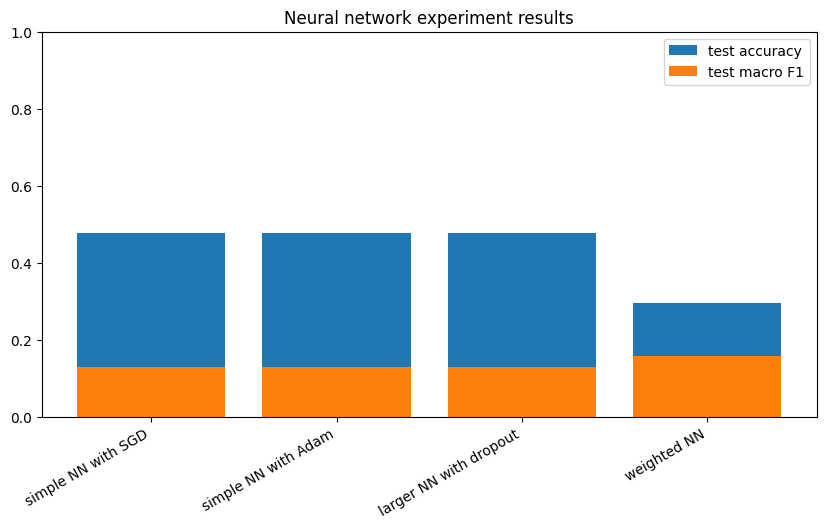

In [24]:
# Results

plot_df = results_df.dropna()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["test_accuracy"], label="test accuracy")
plt.bar(plot_df["model"], plot_df["test_macro_f1"], label="test macro F1")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("Neural network experiment results")
plt.legend()
plt.show()


Best model based on validation macro F1: weighted NN
              precision    recall  f1-score   support

           1       0.03      0.66      0.05       258
           2       0.18      0.00      0.01      2155
           3       0.49      0.49      0.49      8646
           4       0.27      0.20      0.23      4674
           5       0.10      0.00      0.00      2358

    accuracy                           0.29     18091
   macro avg       0.21      0.27      0.16     18091
weighted avg       0.34      0.29      0.30     18091



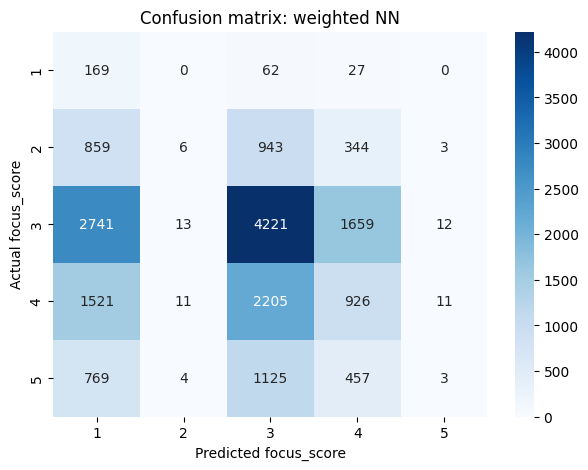

,temperature_latest,temperature_mean,temperature_min,temperature_max,temperature_std,temperature_count,temperature_range,humidity_latest,humidity_mean,humidity_min,...,noise_range,co2_latest,co2_mean,co2_min,co2_max,co2_std,co2_count,co2_range,actual_focus_score,predicted_focus_score
40349,26.800,26.866667,26.800,26.90,5.163978e-02,6,0.100,2116.000000,2116.000000,2116.0000,...,0.900584,0.001916,0.001941,0.001916,0.001972,0.000023,6,0.000057,3,1
38765,28.100,28.100000,28.100,28.10,3.891803e-15,6,0.000,3136.000000,3136.000000,3136.0000,...,0.359098,0.001364,0.001374,0.001348,0.001403,0.000019,6,0.000055,3,1
46170,18.400,18.416667,18.400,18.50,4.082483e-02,6,0.100,4489.000000,4534.000000,4489.0000,...,0.792124,0.001404,0.001290,0.001153,0.001404,0.000098,6,0.000251,1,3
4375,27.000,26.966667,26.900,27.00,5.163978e-02,6,0.100,2116.000000,2116.000000,2116.0000,...,0.658562,0.001931,0.001953,0.001880,0.002062,0.000065,6,0.000182,2,1
89133,18.000,18.216667,17.200,18.80,6.013873e-01,6,1.600,2209.000000,2272.666667,2209.0000,...,0.928932,0.001848,0.001706,0.001550,0.001848,0.000106,6,0.000298,4,3
71392,23.505,23.564417,23.505,23.63,3.539876e-02,30,0.125,3112.338136,3099.882931,3089.1364,...,0.473472,0.002677,0.002688,0.002644,0.002734,0.000026,30,0.000090,4,1
47862,20.000,19.580000,19.000,20.00,4.024922e-01,5,1.000,3969.000000,3605.200000,3249.0000,...,0.394051,0.001017,0.000922,0.000858,0.001017,0.000063,5,0.000160,4,3
11504,20.400,20.416667,20.400,20.50,4.082483e-02,6,0.100,3136.000000,3117.500000,3025.0000,...,0.588144,0.000762,0.000757,0.000730,0.000772,0.000014,6,0.000042,4,3
42953,23.000,22.850000,22.700,23.00,1.048809e-01,6,0.300,3249.000000,3249.000000,3249.0000,...,0.513629,0.002283,0.002210,0.002155,0.002283,0.000044,6,0.000128,3,1
39661,28.700,28.566667,28.500,28.70,8.164966e-02,6,0.200,2304.000000,2304.000000,2304.0000,...,0.321481,0.000523,0.000586,0.000523,0.000664,0.000053,6,0.000141,2,1


In [25]:
# Best model details

best_name = results_df.dropna().sort_values("val_macro_f1", ascending=False).iloc[0]["model"]
best_model = trained_models[best_name]

print(f"Best model based on validation macro F1: {best_name}")

test_probabilities = best_model.predict(X_test_scaled, verbose=0)
test_predictions = decode_predictions(test_probabilities)

print(classification_report(y_test, test_predictions, labels=focus_score_values, zero_division=0))

cm = confusion_matrix(y_test, test_predictions, labels=focus_score_values)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=focus_score_values, yticklabels=focus_score_values)
plt.xlabel("Predicted focus_score")
plt.ylabel("Actual focus_score")
plt.title(f"Confusion matrix: {best_name}")
plt.show()

errors = X_test.copy()
errors["actual_focus_score"] = y_test.values
errors["predicted_focus_score"] = test_predictions
display(errors[errors["actual_focus_score"] != errors["predicted_focus_score"]].head(15))


## Conclusion
# TODO update conlusion because the data changed

The neural network is viable, but only partly.

It performs much better than always predicting the most common focus_score. In my run, the simple neural network reached around 80% test accuracy, while the majority baseline was around 53%.

However, the dataset is very imbalanced. focus_score 3 and 4 dominate the data, while focus_score 2 and 5 have very few rows. Because of that, normal accuracy looks better than the model really is. Macro F1 is more honest here.

The weighted neural network is interesting because it gives more attention to rare classes. It usually lowers accuracy, but improves macro F1 and detects focus_score 2 and 5 better.

For SEP, neural networks can be tested, but they are probably not the best final model yet. The dataset is small and imbalanced, so simpler models may be easier to explain and maintain. A neural network becomes more relevant if we collect more real and balanced data.
